# 06_prediction.ipynb

In [1]:
import sys
print(sys.executable)

/Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/.venv-segformer/bin/python


In [4]:
import os
import sys
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

In [5]:
project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root))

print("Project root:", project_root)

unet_out = project_root / "outputs" / "unet"
deeplab_out = project_root / "outputs" / "deeplabv3plus"
segformer_out = project_root / "outputs" / "segformer"

subset_test_path = project_root / "data" / "subsets" / "subset_test_500.txt"

print("U-Net output exists:", unet_out.exists())
print("DeepLab output exists:", deeplab_out.exists())
print("SegFormer output exists:", segformer_out.exists())
print("Subset file exists:", subset_test_path.exists())

Project root: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch
U-Net output exists: True
DeepLab output exists: True
SegFormer output exists: True
Subset file exists: True


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [7]:
def load_yaml(path):
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

unet_config = load_yaml(unet_out / "config_used.yaml")
deeplab_config = load_yaml(deeplab_out / "config_used.yaml")
segformer_config = load_yaml(segformer_out / "config_used.yaml")

print("Loaded configs:")
print("U-Net keys:", list(unet_config.keys())[:10])
print("DeepLab keys:", list(deeplab_config.keys())[:10])
print("SegFormer keys:", list(segformer_config.keys())[:10])

Loaded configs:
U-Net keys: ['model_name', 'input_channels', 'num_classes', 'data_root', 'train_split', 'val_split', 'test_split', 'image_size', 'batch_size', 'num_epochs']
DeepLab keys: ['model_name', 'input_channels', 'num_classes', 'data_root', 'train_split', 'val_split', 'test_split', 'image_size', 'batch_size', 'num_epochs']
SegFormer keys: ['model_name', 'input_channels', 'num_classes', 'data_root', 'train_split', 'val_split', 'test_split', 'image_size', 'batch_size', 'num_epochs']


In [9]:
unet_ckpt = unet_out / "best_unet.pt"
deeplab_ckpt = deeplab_out / "best_deeplabv3plus.pt"
segformer_ckpt = segformer_out / "best_segformer.pt"

print("U-Net checkpoint:", unet_ckpt.exists(), unet_ckpt)
print("DeepLab checkpoint:", deeplab_ckpt.exists(), deeplab_ckpt)
print("SegFormer checkpoint:", segformer_ckpt.exists(), segformer_ckpt)

U-Net checkpoint: True /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/outputs/unet/best_unet.pt
DeepLab checkpoint: True /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/outputs/deeplabv3plus/best_deeplabv3plus.pt
SegFormer checkpoint: True /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/outputs/segformer/best_segformer.pt


In [10]:
with open(subset_test_path, "r", encoding="utf-8") as f:
    shared_test_ids = [line.strip() for line in f if line.strip()]

print("Number of shared test IDs:", len(shared_test_ids))
print("First 10 IDs:", shared_test_ids[:10])

Number of shared test IDs: 500
First 10 IDs: ['00006', '00021', '00066', '00067', '00077', '00083', '00106', '00107', '00115', '00116']


In [13]:
from src.data_utils import SYSUCDDataset
from torch.utils.data import DataLoader

# 1. load all test data
test_dataset = SYSUCDDataset(
    root_dir=project_root / "data",
    split="test"
)

# 2. load subset ids
with open(subset_test_path, "r", encoding="utf-8") as f:
    shared_test_ids = [line.strip() for line in f if line.strip()]

shared_test_ids = set(shared_test_ids)

# 3. filter dataset to only subset_test_500
test_dataset.sample_ids = [
    file_name for file_name in test_dataset.sample_ids
    if file_name.replace(".png", "") in shared_test_ids
]

# 4. build loader
test_loader = DataLoader(
    test_dataset,
    batch_size=segformer_config.get("batch_size", 8),
    shuffle=False,
    num_workers=segformer_config.get("num_workers", 0),
)

print("Filtered test dataset size:", len(test_dataset))
print("First 10 sample ids:", test_dataset.sample_ids[:10])

Filtered test dataset size: 500
First 10 sample ids: ['00006.png', '00021.png', '00066.png', '00067.png', '00077.png', '00083.png', '00106.png', '00107.png', '00115.png', '00116.png']


In [15]:
import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
from tqdm import tqdm

def extract_logits(outputs):
    if isinstance(outputs, dict):
        if "logits" in outputs:
            return outputs["logits"]
        if "out" in outputs:
            return outputs["out"]
    if hasattr(outputs, "logits"):
        return outputs.logits
    return outputs


def save_full_predictions(
    model,
    test_loader,
    device,
    save_dir,
    threshold=0.5,
    target_size=(256, 256)
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    model.eval()
    saved_ids = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Saving to {save_dir.name}"):
            images = batch["image"].to(device)
            sample_ids = batch["id"]

            outputs = model(images)
            logits = extract_logits(outputs)

            if logits.ndim == 3:
                logits = logits.unsqueeze(1)

            if logits.shape[-2:] != target_size:
                logits = F.interpolate(
                    logits,
                    size=target_size,
                    mode="bilinear",
                    align_corners=False
                )

            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()
            preds = preds.squeeze(1).cpu().numpy()

            for pred, sample_id in zip(preds, sample_ids):
                pred_img = Image.fromarray((pred * 255).astype("uint8"))
                pred_img.save(save_dir / f"{sample_id}_pred.png")
                saved_ids.append(sample_id)

    print(f"Saved {len(saved_ids)} masks to: {save_dir}")
    return saved_ids

In [16]:
segformer_ckpt = project_root / "outputs" / "segformer" / "best_segformer.pt"
print(segformer_ckpt.exists(), segformer_ckpt)

True /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/outputs/segformer/best_segformer.pt


In [17]:
import torch.nn as nn

In [19]:
import torch.nn as nn
from transformers import SegformerConfig, SegformerForSemanticSegmentation

segformer_hf_config = SegformerConfig(
    num_channels=6,
    num_labels=1,
    depths=segformer_config.get("depths", [2, 2, 2, 2]),
    hidden_sizes=segformer_config.get("hidden_sizes", [32, 64, 160, 256]),
    decoder_hidden_size=segformer_config.get("decoder_hidden_size", 256),
    sr_ratios=segformer_config.get("sr_ratios", [8, 4, 2, 1]),
    patch_sizes=segformer_config.get("patch_sizes", [7, 3, 3, 3]),
    strides=segformer_config.get("strides", [4, 2, 2, 2]),
    num_attention_heads=segformer_config.get("num_attention_heads", [1, 2, 5, 8]),
    mlp_ratios=segformer_config.get("mlp_ratios", [4, 4, 4, 4]),
    hidden_act="gelu",
    hidden_dropout_prob=0.0,
    attention_probs_dropout_prob=0.0,
    classifier_dropout_prob=0.1,
    reshape_last_stage=True,
    semantic_loss_ignore_index=255,
)

segformer_model = SegformerForSemanticSegmentation(segformer_hf_config)

print("SegFormer model created.")
print("Num params:", sum(p.numel() for p in segformer_model.parameters()))

/Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/.venv-segformer/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


SegFormer model created.
Num params: 3719105


In [20]:
segformer_ckpt = project_root / "outputs" / "segformer" / "best_segformer.pt"
print("Checkpoint exists:", segformer_ckpt.exists(), segformer_ckpt)

Checkpoint exists: True /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/outputs/segformer/best_segformer.pt


In [22]:
state_dict = torch.load(segformer_ckpt, map_location=device)

# remove "model." prefix
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith("model."):
        new_state_dict[k[len("model."):]] = v
    else:
        new_state_dict[k] = v

segformer_model.load_state_dict(new_state_dict)
segformer_model.to(device)
segformer_model.eval()

print("SegFormer checkpoint loaded successfully.")

SegFormer checkpoint loaded successfully.


In [23]:
segformer_full_dir = project_root / "outputs" / "segformer" / "test_predictions_full"

saved_segformer_ids = save_full_predictions(
    model=segformer_model,
    test_loader=test_loader,
    device=device,
    save_dir=segformer_full_dir,
    threshold=0.5,
    target_size=(256, 256)
)

print("Saved predictions:", len(saved_segformer_ids))
print("First 10 saved IDs:", saved_segformer_ids[:10])

Saving to test_predictions_full: 100%|██████████| 63/63 [00:53<00:00,  1.18it/s]

Saved 500 masks to: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/outputs/segformer/test_predictions_full
Saved predictions: 500
First 10 saved IDs: ['00006', '00021', '00066', '00067', '00077', '00083', '00106', '00107', '00115', '00116']


In [24]:
from pathlib import Path

num_saved = len(list(Path(segformer_full_dir).glob("*.png")))
print("SegFormer full predictions:", num_saved)

SegFormer full predictions: 500


In [25]:
show_files = sorted(Path(segformer_full_dir).glob("*.png"))[:10]
[f.name for f in show_files]

['00006_pred.png',
 '00021_pred.png',
 '00066_pred.png',
 '00067_pred.png',
 '00077_pred.png',
 '00083_pred.png',
 '00106_pred.png',
 '00107_pred.png',
 '00115_pred.png',
 '00116_pred.png']

In [26]:
len(list(Path(segformer_full_dir).glob("*.png")))

500

# DeepLabV3+

In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path

In [31]:
# Define the basic building blocks for DeepLabV3+
class ConvBNReLU(nn.Sequential):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, dilation=1):
        super().__init__(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )


class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                padding=dilation,
                dilation=dilation,
                groups=in_channels,
                bias=False,
            ),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ASPPConv(nn.Sequential):
    def __init__(self, in_channels, out_channels, dilation):
        super().__init__(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=dilation,
                dilation=dilation,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )


class ASPPPooling(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        size = x.shape[-2:]
        pooled = self.pool(x)
        pooled = self.conv(pooled)
        return F.interpolate(pooled, size=size, mode="bilinear", align_corners=False)


class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=256, atrous_rates=(6, 12, 18)):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ),
            ASPPConv(in_channels, out_channels, atrous_rates[0]),
            ASPPConv(in_channels, out_channels, atrous_rates[1]),
            ASPPConv(in_channels, out_channels, atrous_rates[2]),
            ASPPPooling(in_channels, out_channels),
        ])

        self.project = nn.Sequential(
            nn.Conv2d(out_channels * len(self.branches), out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )

    def forward(self, x):
        features = [branch(x) for branch in self.branches]
        x = torch.cat(features, dim=1)
        return self.project(x)


class SimpleBackbone(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.stage1 = nn.Sequential(
            ConvBNReLU(in_channels, 64, stride=2),
            ConvBNReLU(64, 64),
        )
        self.stage2 = nn.Sequential(
            ConvBNReLU(64, 128, stride=2),
            ConvBNReLU(128, 128),
        )
        self.stage3 = nn.Sequential(
            ConvBNReLU(128, 256, stride=2),
            ConvBNReLU(256, 256),
        )
        self.stage4 = nn.Sequential(
            ConvBNReLU(256, 512, stride=2),
            ConvBNReLU(512, 512),
        )

    def forward(self, x):
        x = self.stage1(x)
        low_level = self.stage2(x)
        x = self.stage3(low_level)
        high_level = self.stage4(x)
        return low_level, high_level


class DeepLabV3Plus(nn.Module):
    def __init__(self, in_channels=6, out_channels=1):
        super().__init__()
        self.backbone = SimpleBackbone(in_channels=in_channels)
        self.aspp = ASPP(in_channels=512, out_channels=256)

        self.low_level_proj = nn.Sequential(
            nn.Conv2d(128, 48, kernel_size=1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
        )

        self.decoder = nn.Sequential(
            DepthwiseSeparableConv(256 + 48, 256),
            DepthwiseSeparableConv(256, 256),
        )

        self.classifier = nn.Conv2d(256, out_channels, kernel_size=1)

    def forward(self, x):
        input_size = x.shape[-2:]
        low_level, high_level = self.backbone(x)

        x = self.aspp(high_level)
        x = F.interpolate(x, size=low_level.shape[-2:], mode="bilinear", align_corners=False)

        low_level = self.low_level_proj(low_level)
        x = torch.cat([x, low_level], dim=1)

        x = self.decoder(x)
        logits = self.classifier(x)
        logits = F.interpolate(logits, size=input_size, mode="bilinear", align_corners=False)
        return logits

In [32]:
deeplab_model = DeepLabV3Plus(
    in_channels=deeplab_config["input_channels"],
    out_channels=deeplab_config["num_classes"]
).to(device)

print("DeepLabV3+ model created.")
print("Num params:", sum(p.numel() for p in deeplab_model.parameters()))

DeepLabV3+ model created.
Num params: 8977905


In [33]:
deeplab_ckpt = project_root / "outputs" / "deeplabv3plus" / "best_deeplabv3plus.pt"
print("Checkpoint exists:", deeplab_ckpt.exists(), deeplab_ckpt)

Checkpoint exists: True /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/outputs/deeplabv3plus/best_deeplabv3plus.pt


In [34]:
deeplab_state = torch.load(deeplab_ckpt, map_location=device)

if isinstance(deeplab_state, dict) and "state_dict" in deeplab_state:
    deeplab_state = deeplab_state["state_dict"]

try:
    deeplab_model.load_state_dict(deeplab_state)
except RuntimeError:
    new_deeplab_state = {}
    for k, v in deeplab_state.items():
        if k.startswith("model."):
            new_deeplab_state[k[len("model."):]] = v
        else:
            new_deeplab_state[k] = v
    deeplab_model.load_state_dict(new_deeplab_state)

deeplab_model.to(device)
deeplab_model.eval()

print("DeepLabV3+ checkpoint loaded successfully.")

DeepLabV3+ checkpoint loaded successfully.


In [37]:
deeplab_full_dir = project_root / "outputs" / "deeplabv3plus" / "test_predictions_full"

saved_deeplab_ids = save_full_predictions(
    model=deeplab_model,
    test_loader=test_loader,
    device=device,
    save_dir=deeplab_full_dir,
    threshold=0.5,
    target_size=(256, 256)
)

print("Saved predictions:", len(saved_deeplab_ids))
print("First 10 saved IDs:", saved_deeplab_ids[:10])

Saving to test_predictions_full: 100%|██████████| 63/63 [00:16<00:00,  3.87it/s]

Saved 500 masks to: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/outputs/deeplabv3plus/test_predictions_full
Saved predictions: 500
First 10 saved IDs: ['00006', '00021', '00066', '00067', '00077', '00083', '00106', '00107', '00115', '00116']


In [38]:
from pathlib import Path

num_saved = len(list(Path(deeplab_full_dir).glob("*.png")))
print("DeepLabV3+ full predictions:", num_saved)

show_files = sorted(Path(deeplab_full_dir).glob("*.png"))[:10]
[f.name for f in show_files]

DeepLabV3+ full predictions: 500


['00006_pred.png',
 '00021_pred.png',
 '00066_pred.png',
 '00067_pred.png',
 '00077_pred.png',
 '00083_pred.png',
 '00106_pred.png',
 '00107_pred.png',
 '00115_pred.png',
 '00116_pred.png']

# U-Net 

In [39]:
import torch
import torch.nn as nn
from pathlib import Path

In [40]:
# Define a basic double convolution block
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# Define a standard U-Net
class UNet(nn.Module):
    def __init__(self, in_channels=6, out_channels=1, base_channels=64):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = DoubleConv(base_channels * 4, base_channels * 8)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_channels * 8, base_channels * 16)

        self.up4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base_channels * 16, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels)

        self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        b = self.bottleneck(self.pool4(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        logits = self.out_conv(d1)
        return logits

In [41]:
unet_model = UNet(
    in_channels=unet_config["input_channels"],
    out_channels=unet_config["num_classes"]
).to(device)

print("U-Net model created.")
print("Num params:", sum(p.numel() for p in unet_model.parameters()))

U-Net model created.
Num params: 31045249


In [42]:
unet_ckpt = project_root / "outputs" / "unet" / "best_unet.pt"
print("Checkpoint exists:", unet_ckpt.exists(), unet_ckpt)

Checkpoint exists: True /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/outputs/unet/best_unet.pt


In [43]:
unet_state = torch.load(unet_ckpt, map_location=device)

if isinstance(unet_state, dict) and "state_dict" in unet_state:
    unet_state = unet_state["state_dict"]

clean_unet_state = {}
for k, v in unet_state.items():
    if k.startswith("model."):
        clean_unet_state[k[len("model."):]] = v
    else:
        clean_unet_state[k] = v

unet_model.load_state_dict(clean_unet_state)
unet_model.to(device)
unet_model.eval()

print("U-Net checkpoint loaded successfully.")

U-Net checkpoint loaded successfully.


In [44]:
unet_full_dir = project_root / "outputs" / "unet" / "test_predictions_full"

saved_unet_ids = save_full_predictions(
    model=unet_model,
    test_loader=test_loader,
    device=device,
    save_dir=unet_full_dir,
    threshold=0.5,
    target_size=(256, 256)
)

print("Saved predictions:", len(saved_unet_ids))
print("First 10 saved IDs:", saved_unet_ids[:10])

Saving to test_predictions_full: 100%|██████████| 63/63 [00:44<00:00,  1.41it/s]

Saved 500 masks to: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/outputs/unet/test_predictions_full
Saved predictions: 500
First 10 saved IDs: ['00006', '00021', '00066', '00067', '00077', '00083', '00106', '00107', '00115', '00116']


In [45]:
num_saved = len(list(Path(unet_full_dir).glob("*.png")))
print("U-Net full predictions:", num_saved)

show_files = sorted(Path(unet_full_dir).glob("*.png"))[:10]
[f.name for f in show_files]

U-Net full predictions: 500


['00006_pred.png',
 '00021_pred.png',
 '00066_pred.png',
 '00067_pred.png',
 '00077_pred.png',
 '00083_pred.png',
 '00106_pred.png',
 '00107_pred.png',
 '00115_pred.png',
 '00116_pred.png']

In [46]:
segformer_full_dir = project_root / "outputs" / "segformer" / "test_predictions_full"
deeplab_full_dir = project_root / "outputs" / "deeplabv3plus" / "test_predictions_full"
unet_full_dir = project_root / "outputs" / "unet" / "test_predictions_full"

print("SegFormer full predictions:", len(list(segformer_full_dir.glob("*.png"))))
print("DeepLabV3+ full predictions:", len(list(deeplab_full_dir.glob("*.png"))))
print("U-Net full predictions:", len(list(unet_full_dir.glob("*.png"))))

SegFormer full predictions: 500
DeepLabV3+ full predictions: 500
U-Net full predictions: 500


In [47]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

gt_dir = project_root / "data" / "test" / "label"
unet_pred_dir = project_root / "outputs" / "unet" / "test_predictions_full"
deeplab_pred_dir = project_root / "outputs" / "deeplabv3plus" / "test_predictions_full"
segformer_pred_dir = project_root / "outputs" / "segformer" / "test_predictions_full"

print("GT:", gt_dir)
print("U-Net preds:", unet_pred_dir)
print("DeepLab preds:", deeplab_pred_dir)
print("SegFormer preds:", segformer_pred_dir)

GT: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/data/test/label
U-Net preds: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/outputs/unet/test_predictions_full
DeepLab preds: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/outputs/deeplabv3plus/test_predictions_full
SegFormer preds: /Users/yuhua/Desktop/Spring26/6600deep learning/DSAN6600-final-project-code-branch/outputs/segformer/test_predictions_full


In [48]:
def list_mask_files(folder):
    return sorted([p for p in Path(folder).glob("*.png")])

def get_patch_id(path):
    return path.stem.replace("_pred", "")

gt_files = list_mask_files(gt_dir)
unet_files = list_mask_files(unet_pred_dir)
deeplab_files = list_mask_files(deeplab_pred_dir)
segformer_files = list_mask_files(segformer_pred_dir)

gt_map = {get_patch_id(p): p for p in gt_files}
unet_map = {get_patch_id(p): p for p in unet_files}
deeplab_map = {get_patch_id(p): p for p in deeplab_files}
segformer_map = {get_patch_id(p): p for p in segformer_files}

shared_names = sorted(set(gt_map) & set(unet_map) & set(deeplab_map) & set(segformer_map))

print("GT files:", len(gt_files))
print("U-Net files:", len(unet_files))
print("DeepLab files:", len(deeplab_files))
print("SegFormer files:", len(segformer_files))
print("Shared files across all 4 folders:", len(shared_names))
print("First 10 shared IDs:", shared_names[:10])

GT files: 4000
U-Net files: 500
DeepLab files: 500
SegFormer files: 500
Shared files across all 4 folders: 500
First 10 shared IDs: ['00006', '00021', '00066', '00067', '00077', '00083', '00106', '00107', '00115', '00116']


In [49]:
pred_df = pd.DataFrame({
    "patch_id": shared_names,
    "gt_path": [gt_map[name] for name in shared_names],
    "unet_path": [unet_map[name] for name in shared_names],
    "deeplab_path": [deeplab_map[name] for name in shared_names],
    "segformer_path": [segformer_map[name] for name in shared_names],
})

pred_df.head()

,patch_id,gt_path,unet_path,deeplab_path,segformer_path
0,00006,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...
1,00021,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...
2,00066,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...
3,00067,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...
4,00077,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...,/Users/yuhua/Desktop/Spring26/6600deep learnin...


In [50]:
def load_binary_mask(path, threshold=127):
    arr = np.array(Image.open(path).convert("L"))
    return (arr > threshold).astype(np.uint8)

In [51]:
def confusion_counts(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = np.logical_and(pred == 1, gt == 1).sum()
    fp = np.logical_and(pred == 1, gt == 0).sum()
    fn = np.logical_and(pred == 0, gt == 1).sum()
    tn = np.logical_and(pred == 0, gt == 0).sum()

    return tp, fp, fn, tn


def metrics_from_counts(tp, fp, fn, tn, eps=1e-8):
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)
    fp_rate = fp / (fp + tn + eps)
    fn_rate = fn / (fn + tp + eps)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
        "fp": fp,
        "fn": fn,
        "fp_rate": fp_rate,
        "fn_rate": fn_rate,
    }

In [52]:
records = []

for _, row in pred_df.iterrows():
    gt = load_binary_mask(row["gt_path"])

    preds = {
        "U-Net": load_binary_mask(row["unet_path"]),
        "DeepLabV3+": load_binary_mask(row["deeplab_path"]),
        "SegFormer": load_binary_mask(row["segformer_path"]),
    }

    for model_name, pred in preds.items():
        tp, fp, fn, tn = confusion_counts(pred, gt)
        m = metrics_from_counts(tp, fp, fn, tn)

        records.append({
            "patch_id": row["patch_id"],
            "model": model_name,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
            **m
        })

results_df = pd.DataFrame(records)
results_df.head()

,patch_id,model,tp,fp,fn,tn,precision,recall,f1,iou,fp_rate,fn_rate
0,00006,U-Net,8908,1886,378,54364,0.825273,0.959294,0.887251,0.797351,0.033529,0.040706
1,00006,DeepLabV3+,8611,1630,675,54620,0.840836,0.927310,0.881958,0.788842,0.028978,0.072690
2,00006,SegFormer,4688,2,4598,56248,0.999574,0.504846,0.670864,0.504737,0.000036,0.495154
3,00021,U-Net,12468,39,1312,51717,0.996882,0.904790,0.948606,0.902236,0.000754,0.095210
4,00021,DeepLabV3+,12928,712,852,51044,0.947801,0.938171,0.942961,0.892078,0.013757,0.061829


In [53]:
summary_records = []

for model_name, group in results_df.groupby("model"):
    tp = group["tp"].sum()
    fp = group["fp"].sum()
    fn = group["fn"].sum()
    tn = group["tn"].sum()

    m = metrics_from_counts(tp, fp, fn, tn)

    summary_records.append({
        "Model": model_name,
        "Precision": m["precision"],
        "Recall": m["recall"],
        "F1": m["f1"],
        "IoU": m["iou"],
        "FP_total": fp,
        "FN_total": fn,
        "FP_rate": m["fp_rate"],
        "FN_rate": m["fn_rate"],
    })

summary_df = pd.DataFrame(summary_records)
summary_df

,Model,Precision,Recall,F1,IoU,FP_total,FN_total,FP_rate,FN_rate
0,DeepLabV3+,0.717778,0.758909,0.737771,0.584498,2302210,1860096,0.091895,0.241091
1,SegFormer,0.746745,0.539122,0.626171,0.455786,1410678,3555827,0.056308,0.460878
2,U-Net,0.691386,0.784813,0.735143,0.581206,2702808,1660242,0.107885,0.215187


In [54]:
summary_df["Automated_Alerting_Rank"] = summary_df["Recall"].rank(ascending=False, method="min")
summary_df["Manual_Inspection_Rank"] = summary_df["Precision"].rank(ascending=False, method="min")

summary_df = summary_df.sort_values("Recall", ascending=False).reset_index(drop=True)
summary_df

,Model,Precision,Recall,F1,IoU,FP_total,FN_total,FP_rate,FN_rate,Automated_Alerting_Rank,Manual_Inspection_Rank
0,U-Net,0.691386,0.784813,0.735143,0.581206,2702808,1660242,0.107885,0.215187,1.0,3.0
1,DeepLabV3+,0.717778,0.758909,0.737771,0.584498,2302210,1860096,0.091895,0.241091,2.0,2.0
2,SegFormer,0.746745,0.539122,0.626171,0.455786,1410678,3555827,0.056308,0.460878,3.0,1.0


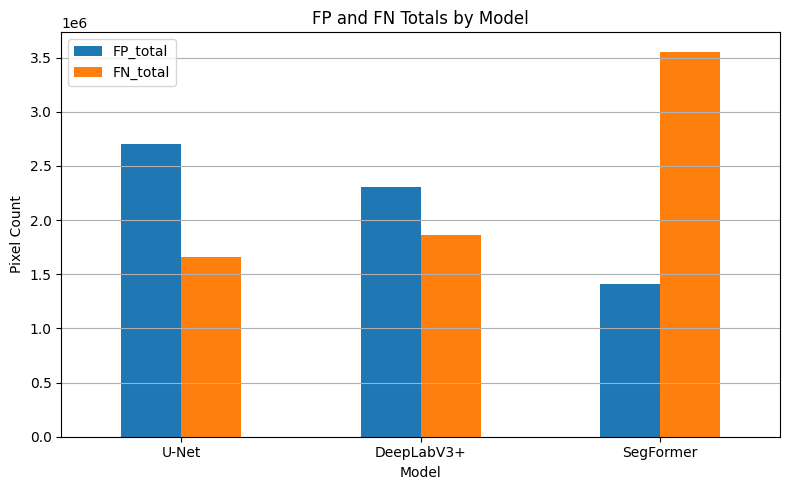

In [55]:
plot_df = summary_df.set_index("Model")[["FP_total", "FN_total"]]

ax = plot_df.plot(kind="bar", figsize=(8, 5))
ax.set_title("FP and FN Totals by Model")
ax.set_xlabel("Model")
ax.set_ylabel("Pixel Count")
ax.grid(True, axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

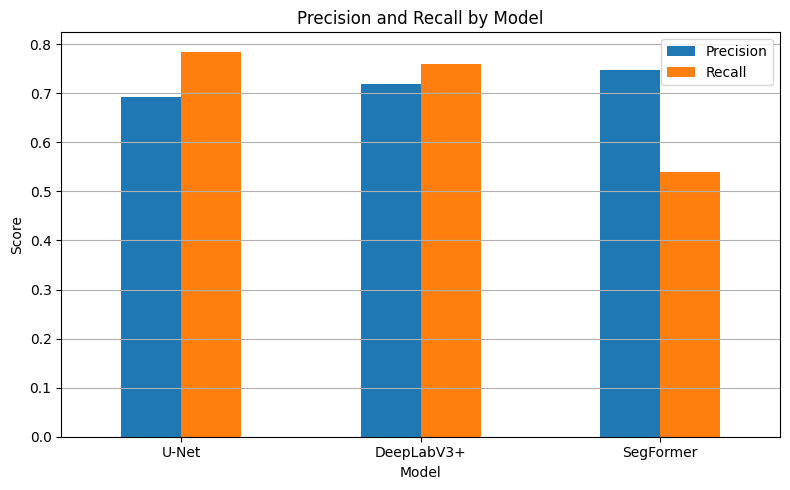

In [58]:
plot_df2 = summary_df.set_index("Model")[["Precision", "Recall"]]

ax = plot_df2.plot(kind="bar", figsize=(8, 5))
ax.set_title("Precision and Recall by Model")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.grid(True, axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [57]:
def build_error_map(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    fp = np.logical_and(pred == 1, gt == 0)
    fn = np.logical_and(pred == 0, gt == 1)

    error_map = np.zeros((*gt.shape, 3), dtype=np.uint8)
    error_map[fp] = [255, 0, 0]   # FP = red
    error_map[fn] = [0, 0, 255]   # FN = blue

    return error_map

In [59]:
example_patches = shared_names[:3]
example_patches

['00006', '00021', '00066']

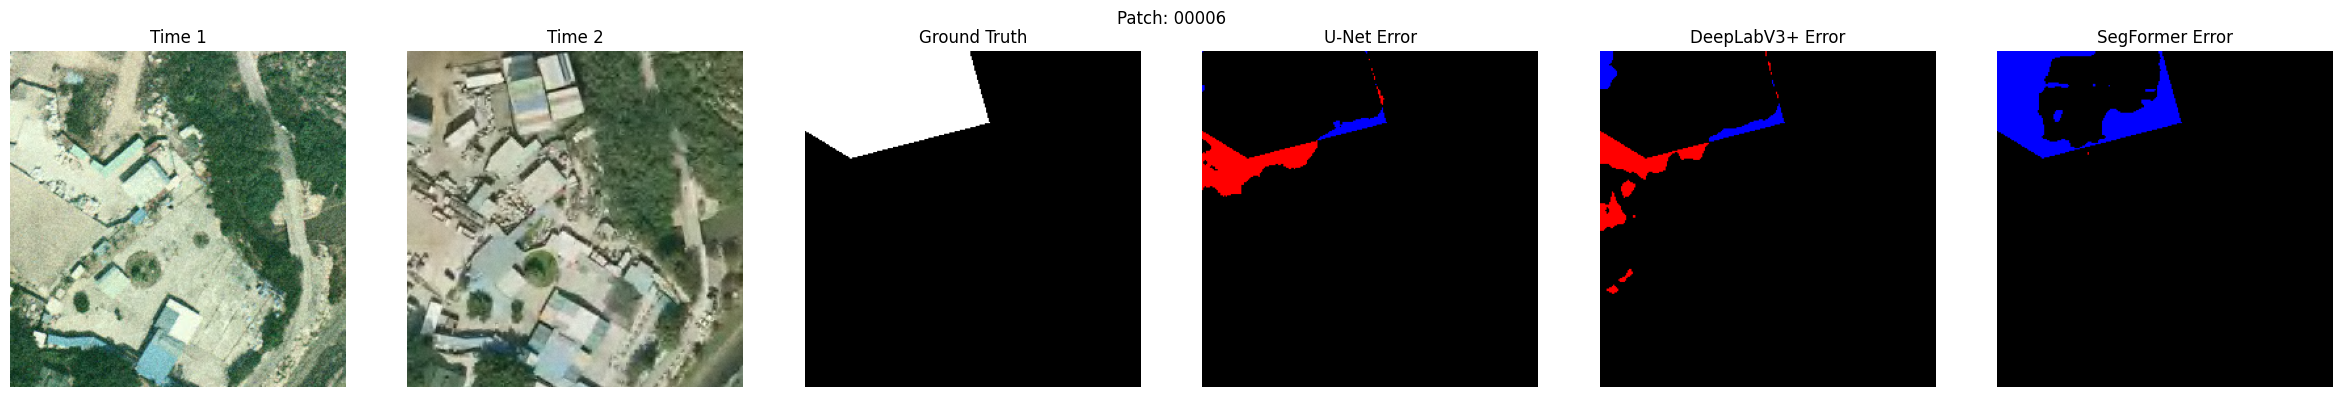

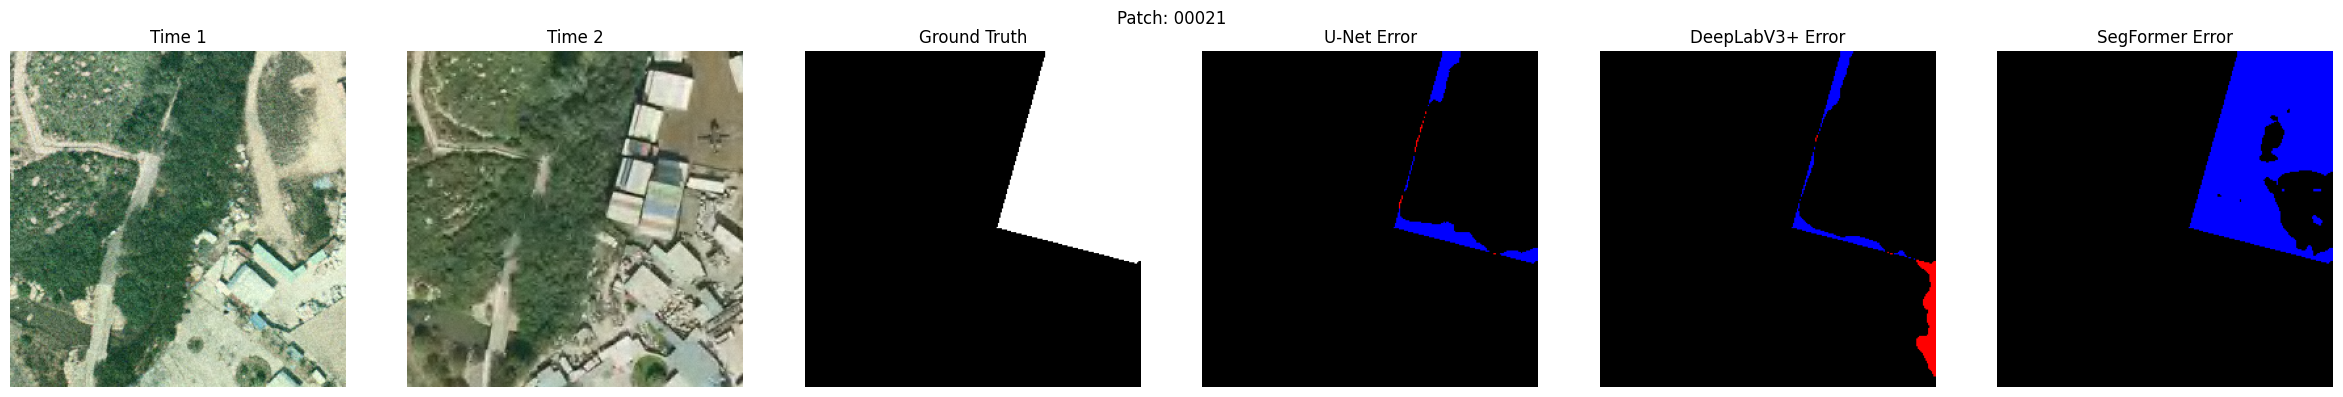

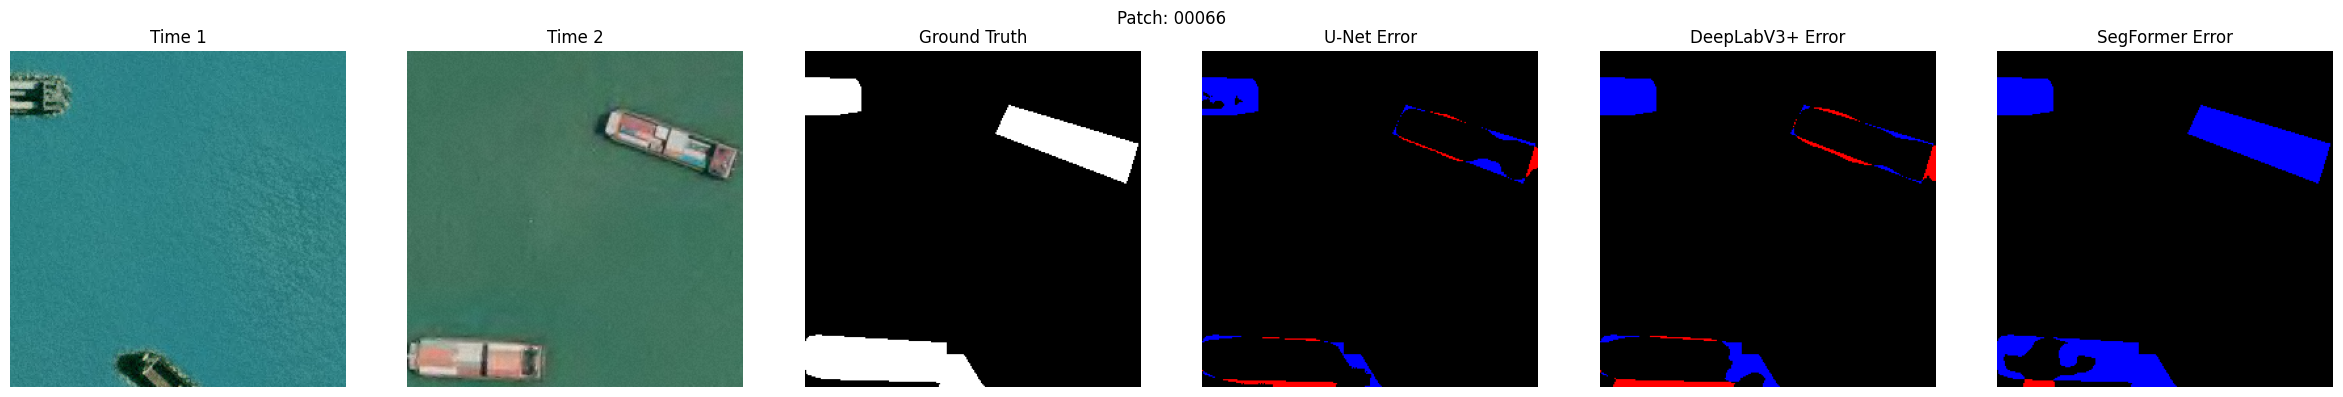

In [62]:
for patch_id in example_patches:
    row = pred_df[pred_df["patch_id"] == patch_id].iloc[0]

    # load original 6-channel input from dataset folders
    time1_path = project_root / "data" / "test" / "time1" / f"{patch_id}.png"
    time2_path = project_root / "data" / "test" / "time2" / f"{patch_id}.png"

    time1 = np.array(Image.open(time1_path).convert("RGB"))
    time2 = np.array(Image.open(time2_path).convert("RGB"))

    gt = load_binary_mask(row["gt_path"])
    unet = load_binary_mask(row["unet_path"])
    deeplab = load_binary_mask(row["deeplab_path"])
    segformer = load_binary_mask(row["segformer_path"])

    fig, axes = plt.subplots(1, 6, figsize=(24, 4))

    axes[0].imshow(time1)
    axes[0].set_title("Time 1")
    axes[0].axis("off")

    axes[1].imshow(time2)
    axes[1].set_title("Time 2")
    axes[1].axis("off")

    axes[2].imshow(gt, cmap="gray")
    axes[2].set_title("Ground Truth")
    axes[2].axis("off")

    axes[3].imshow(build_error_map(unet, gt))
    axes[3].set_title("U-Net Error")
    axes[3].axis("off")

    axes[4].imshow(build_error_map(deeplab, gt))
    axes[4].set_title("DeepLabV3+ Error")
    axes[4].axis("off")

    axes[5].imshow(build_error_map(segformer, gt))
    axes[5].set_title("SegFormer Error")
    axes[5].axis("off")

    plt.suptitle(f"Patch: {patch_id}")
    plt.tight_layout()
    plt.show()

哪些地方模型多报了（红色）
哪些地方模型漏掉了（蓝色）

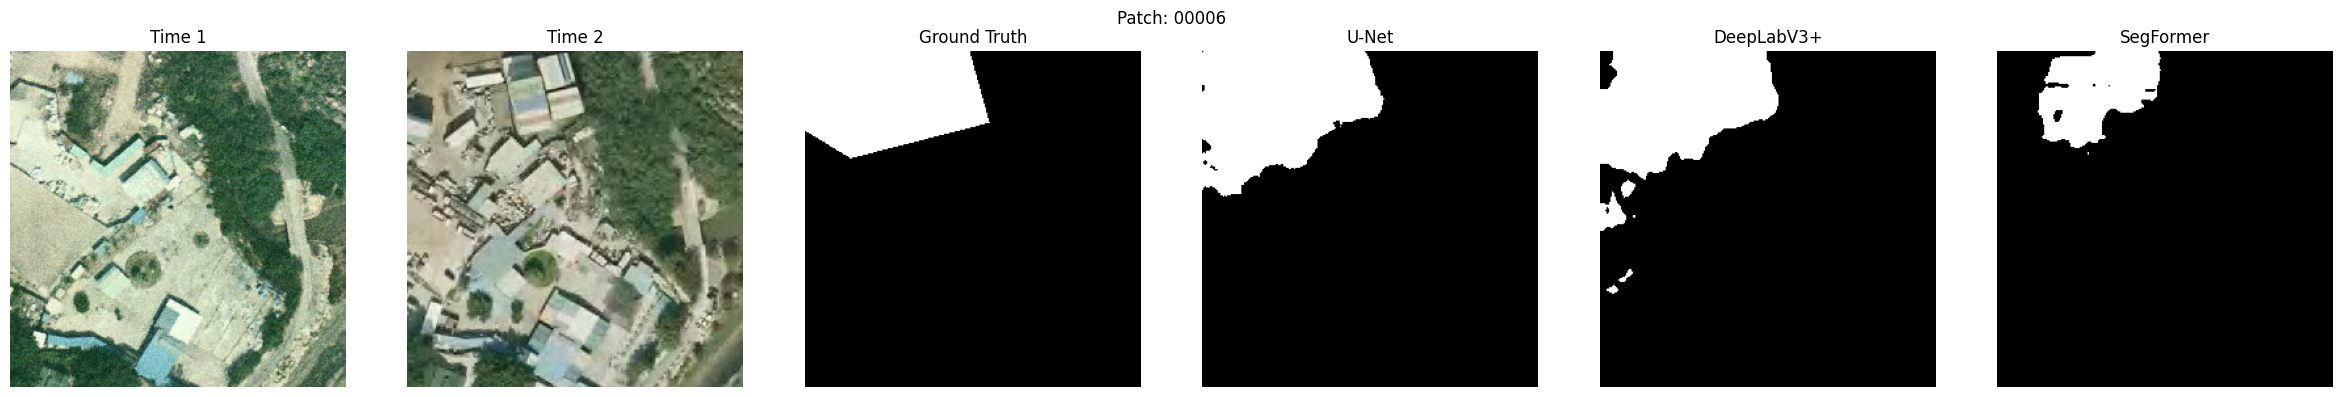

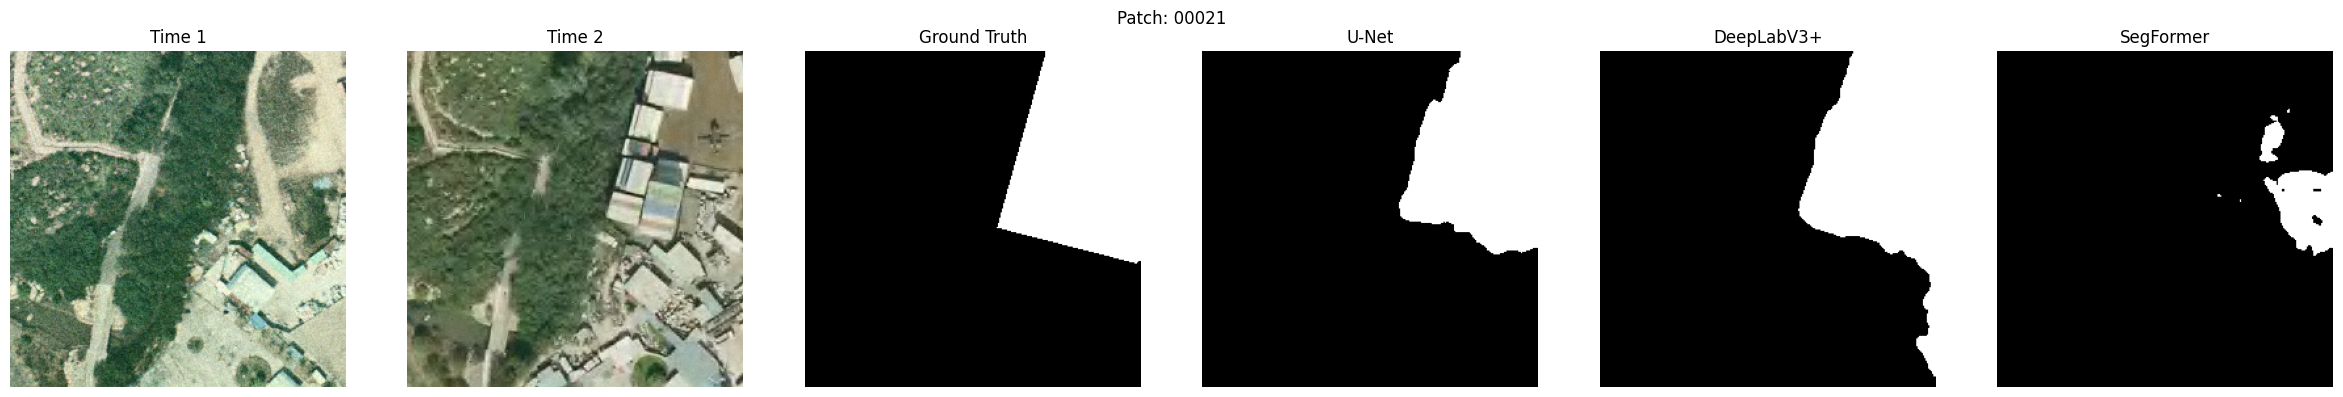

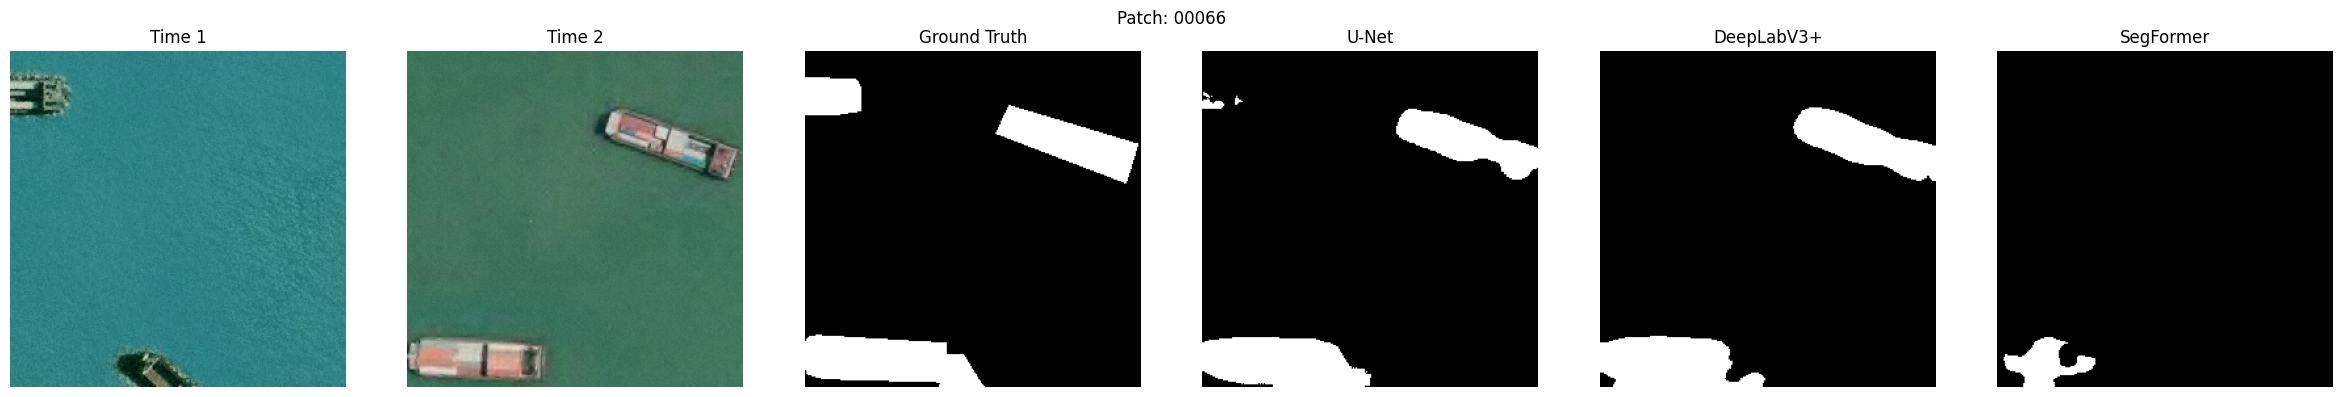

In [64]:
for patch_id in example_patches:
    row = pred_df[pred_df["patch_id"] == patch_id].iloc[0]

    time1_path = project_root / "data" / "test" / "time1" / f"{patch_id}.png"
    time2_path = project_root / "data" / "test" / "time2" / f"{patch_id}.png"

    time1 = np.array(Image.open(time1_path).convert("RGB"))
    time2 = np.array(Image.open(time2_path).convert("RGB"))

    gt = load_binary_mask(row["gt_path"])
    unet = load_binary_mask(row["unet_path"])
    deeplab = load_binary_mask(row["deeplab_path"])
    segformer = load_binary_mask(row["segformer_path"])

    fig, axes = plt.subplots(1, 6, figsize=(24, 4))

    axes[0].imshow(time1)
    axes[0].set_title("Time 1")
    axes[0].axis("off")

    axes[1].imshow(time2)
    axes[1].set_title("Time 2")
    axes[1].axis("off")

    axes[2].imshow(gt, cmap="gray")
    axes[2].set_title("Ground Truth")
    axes[2].axis("off")

    axes[3].imshow(unet, cmap="gray")
    axes[3].set_title("U-Net")
    axes[3].axis("off")

    axes[4].imshow(deeplab, cmap="gray")
    axes[4].set_title("DeepLabV3+")
    axes[4].axis("off")

    axes[5].imshow(segformer, cmap="gray")
    axes[5].set_title("SegFormer")
    axes[5].axis("off")

    plt.suptitle(f"Patch: {patch_id}")
    plt.tight_layout()
    plt.show()